In [29]:
from scipy.sparse import load_npz,save_npz,diags,csr_matrix,issparse
import json
import numpy as np
import matplotlib.pyplot as plt

In [30]:
# Choose the disease to analyze
DISEASE = input("Disease: ")

In [31]:
# Load all the matrices needed
OUTPUT_DIRECTORY = f"../output/{DISEASE}/"
DGIDB_DIRECTORY = f"../Gen_Hypergraph/output/DGIDB_{DISEASE}/"
MSIGDB_DIRECTORY = "../Gen_Hypergraph/output/MSigDB_Full/"
DISEASE_FOLDER = f"../Methods/output/{DISEASE}/"

## DGIDB
DGIDB_binary_matrix = load_npz(DGIDB_DIRECTORY + "hypergraph_incidence_matrix_binary.npz")
DGIDB_weighted_matrix = load_npz(DGIDB_DIRECTORY + "hypergraph_incidence_matrix_weighted.npz")
DGIDB_gene_weight_diag_matrix = load_npz(DGIDB_DIRECTORY + "diag_gene_weight_matrix.npz")
DGIDB_diag_node_degree_matrix = load_npz(DGIDB_DIRECTORY + "diag_node_degree_matrix.npz")
DGIDB_inverse_diag_edge_degree_matrix = load_npz(
    DGIDB_DIRECTORY + "inverse_diag_edge_degree_matrix.npz"
    )

## MSIGDB
MSIGDB_binary_matrix = load_npz(MSIGDB_DIRECTORY + "hypergraph_incidence_matrix_binary.npz")
MSIGDB_weighted_matrix = load_npz(MSIGDB_DIRECTORY + "hypergraph_incidence_matrix_weighted.npz")
MSIGDB_gene_weight_diag_matrix = load_npz(MSIGDB_DIRECTORY + "gene_weight_diag_matrix.npz")
MSIGDB_diag_node_degree_matrix = load_npz(MSIGDB_DIRECTORY + "diag_node_degree_matrix.npz")
MSIGDB_inverse_diag_edge_degree_matrix = load_npz(
    MSIGDB_DIRECTORY + "inverse_diag_edge_degree_matrix.npz"
    )

with open(DISEASE_FOLDER + "gene_to_index_distinct.json", "r") as file:
    gene_to_index_distinct = json.load(file)

FileNotFoundError: [Errno 2] No such file or directory: '../Gen_Hypergraph/output/DGIDB_/hypergraph_incidence_matrix_binary.npz'

In [ ]:
# Number of Genes
print("Number of genes:",len(gene_to_index_distinct))

Number of genes: 21988


In [ ]:
# Number of DGIDB Genes
print("Number of DGIDB genes:",DGIDB_binary_matrix.shape[0])

Number of DGIDB genes: 249


In [ ]:
# Number of MSigDB Genes
print("Number of MSigDB genes:",MSIGDB_binary_matrix.shape[0])

Number of MSigDB genes: 21981


In [ ]:
# Percent of shared genes between DGIDB and MSigDB

# Open the JSON file and load its content into a dictionary
with open(DGIDB_DIRECTORY + f"gene_to_index.json", "r") as file:
    DGIDB_gene_to_index = json.load(file)
with open(MSIGDB_DIRECTORY + "gene_to_index.json", "r") as file:
    MSIGDB_gene_to_index = json.load(file)

DGIDB_index_to_gene = {index: gene for gene, index in DGIDB_gene_to_index.items()}   
# Jump probability for matching genes
w = 1

# Number of genes (assuming they are both of same size or matchable)
num_genes_dgidb = len(DGIDB_gene_to_index)
num_genes_msigdb = len(MSIGDB_gene_to_index)

# Initialize the inter-layer matrix with zeros
interlayer_transition_matrix = np.zeros((num_genes_msigdb,num_genes_dgidb))
i = 0
# Build the inter-layer matrix
for gene_dgidb, idx_dgidb in DGIDB_gene_to_index.items():
    # If the gene exists in both gene-to-index mappings
    if gene_dgidb in MSIGDB_gene_to_index:      
        idx_msigdb = MSIGDB_gene_to_index[gene_dgidb]
        interlayer_transition_matrix[idx_msigdb,idx_dgidb] = w  # Set jump probability
        i += 1

print(f"{i/len(gene_to_index_distinct):.2%}", "of genes are shared between the two layers")

1.10% of genes are shared between the two layers


In [ ]:
# Number of DGIDB edges
print("Number of DGIDB edges:",DGIDB_binary_matrix.shape[1])

Number of DGIDB edges: 11


In [ ]:
# Number of MSigDB edges
print("Number of MSigDB edges:",MSIGDB_binary_matrix.shape[1])

Number of MSigDB edges: 7411


In [37]:
def plot_two_hypergraph_distributions(H1,size = (12, 3), savepath=None):
    """
    Plot hyperedge-size and node-degree distributions for ONE incidence matrix.

    Layout:
        H1 hyperedge size (left), H1 node degree (right)
    """

    def compute_sizes_degrees(H):
        if issparse(H):
            H_bool = H.astype(bool)
            sizes = np.asarray(H_bool.sum(axis=0)).ravel()
            degrees = np.asarray(H_bool.sum(axis=1)).ravel()
        else:
            H_bool = (np.asarray(H) != 0)
            sizes = H_bool.sum(axis=0)
            degrees = H_bool.sum(axis=1)
        return sizes, degrees

    # Compute for H1 only
    sizes1, degrees1 = compute_sizes_degrees(H1)

    # Bins
    def make_bins(x):
        if len(x) == 0:
            return np.arange(0.5, 2.5, 1)
        m = int(x.max())
        return np.arange(0.5, m + 1.5, 1)

    bins_sizes1 = make_bins(sizes1)
    bins_degrees1 = make_bins(degrees1)

    # Percentage weights
    w_sizes1 = np.ones_like(sizes1, dtype=float) / len(sizes1) * 100
    w_degrees1 = np.ones_like(degrees1, dtype=float) / len(degrees1) * 100

    # ------ Create a 1x2 grid ------
    fig, axes = plt.subplots(1, 2, figsize=size)  # changed: 1 row, 2 columns

    fig.subplots_adjust(
        top=0.85,
        wspace=0.25
    )  # changed: removed vertical row spacing

    # Hyperedge sizes
    axes[0].hist(sizes1, bins=bins_sizes1, weights=w_sizes1, edgecolor="black")
    axes[0].set_title("DGIDB Hyperedge Size Distribution")
    axes[0].set_xlabel("Hyperedge Size (# of Nodes)")
    axes[0].set_ylabel("Percentage (%)")

    # Node degrees
    axes[1].hist(degrees1, bins=bins_degrees1, weights=w_degrees1, edgecolor="black")
    axes[1].set_title("DGIDB Node Degree Distribution")
    axes[1].set_xlabel("Node Degree (# of Hyperedges)")
    axes[1].set_ylabel("Percentage (%)")

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')

    return fig, axes

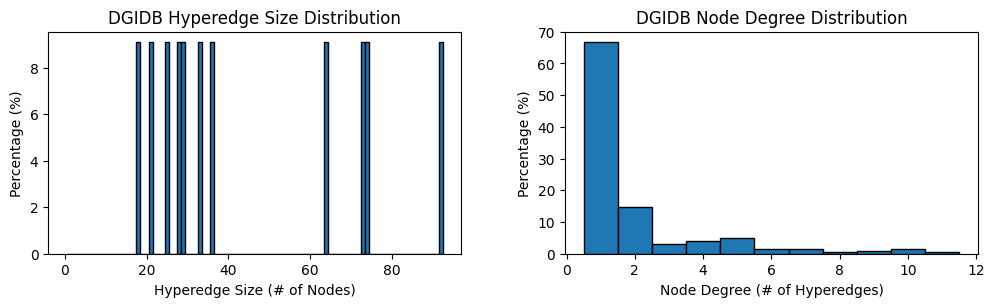

In [38]:
plot_two_hypergraph_distributions(DGIDB_binary_matrix, savepath = f"../Graphs/{DISEASE}/hypergraph_overview.png")
plt.show()

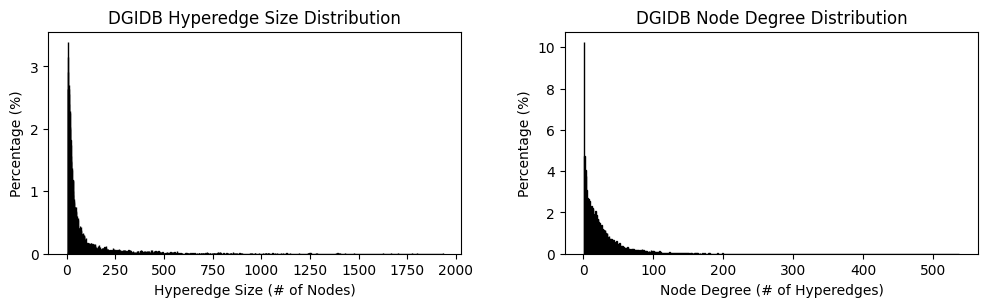

In [ ]:
# plot_two_hypergraph_distributions(MSIGDB_binary_matrix, savepath = f"../Graphs/NONE/hypergraph_overview.png")
# plt.show()